In [5]:
from google.colab import files

uploaded = files.upload()

Saving dbscan.xlsx to dbscan.xlsx


In [7]:
import pandas as pd

df = pd.read_excel("dbscan.xlsx")

print(df.head())
print(df.columns)

  Ward,Latitude,Longitude,SWSI
0        W1,18.6200,73.8000,89
1        W2,18.6205,73.8008,85
2        W3,18.6210,73.8012,87
3        W4,18.6215,73.8018,82
4        W5,18.6220,73.8020,90
Index(['Ward,Latitude,Longitude,SWSI'], dtype='object')


In [8]:
import pandas as pd

df = pd.read_excel("dbscan.xlsx")

df = df.iloc[:,0].str.split(",", expand=True)

df.columns = ["Ward","Latitude","Longitude","SWSI"]

df["Latitude"] = df["Latitude"].astype(float)
df["Longitude"] = df["Longitude"].astype(float)
df["SWSI"] = df["SWSI"].astype(float)

print(df.head())

  Ward  Latitude  Longitude  SWSI
0   W1   18.6200    73.8000  89.0
1   W2   18.6205    73.8008  85.0
2   W3   18.6210    73.8012  87.0
3   W4   18.6215    73.8018  82.0
4   W5   18.6220    73.8020  90.0


In [9]:
from sklearn.cluster import DBSCAN

coords = df[['Latitude','Longitude']]

dbscan = DBSCAN(
    eps=0.003,
    min_samples=5
)

df['Cluster'] = dbscan.fit_predict(coords)

print(df.head())

print(
    "Clusters:",
    len(set(df['Cluster'])) - (1 if -1 in df['Cluster'] else 0)
)

print(
    "Noise Points:",
    list(df['Cluster']).count(-1)
)

  Ward  Latitude  Longitude  SWSI  Cluster
0   W1   18.6200    73.8000  89.0        0
1   W2   18.6205    73.8008  85.0        0
2   W3   18.6210    73.8012  87.0        0
3   W4   18.6215    73.8018  82.0        0
4   W5   18.6220    73.8020  90.0        0
Clusters: 3
Noise Points: 0


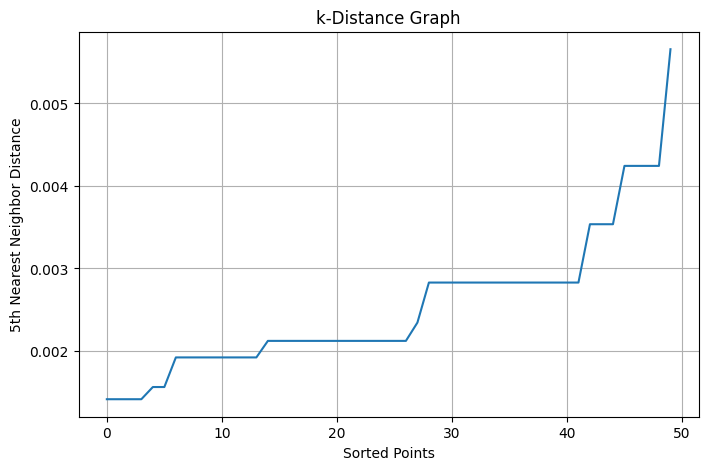

In [10]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(coords)

distances, indices = neighbors_fit.kneighbors(coords)

distances = np.sort(distances[:,4])

plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("k-Distance Graph")
plt.xlabel("Sorted Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.grid(True)

plt.show()

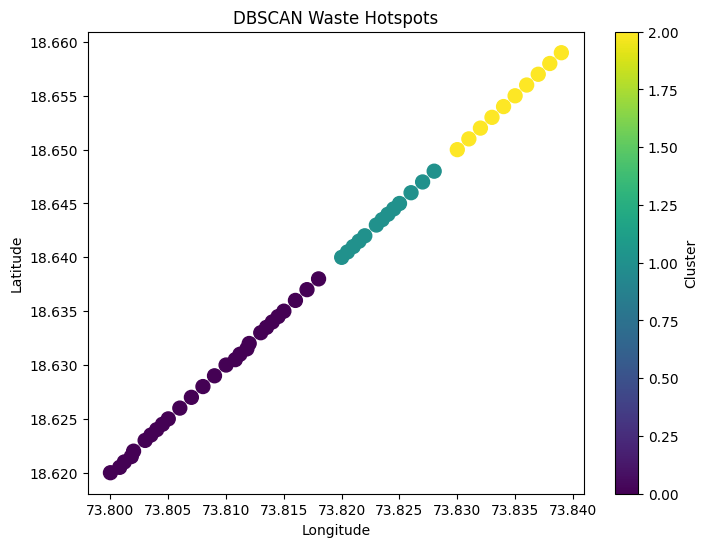

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Cluster'],
    s=100
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("DBSCAN Waste Hotspots")

plt.colorbar(label="Cluster")

plt.show()

In [12]:
hotspots = df.groupby('Cluster').agg({
    'SWSI':'mean',
    'Latitude':'mean',
    'Longitude':'mean'
}).reset_index()

hotspots['Priority'] = hotspots['SWSI'].rank(
    ascending=False
)

print(hotspots)

   Cluster       SWSI   Latitude  Longitude  Priority
0        0  79.111111  18.628556  73.808615       1.0
1        1  45.307692  18.643538  73.823538       2.0
2        2  20.700000  18.654500  73.834500       3.0


In [15]:
from sklearn.cluster import DBSCAN

# Change parameters here
eps = 0.003
min_samples = 3

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

df['Cluster'] = dbscan.fit_predict(
    df[['Latitude','Longitude']]
)

print("Clusters:",
      len(set(df['Cluster'])) -
      (1 if -1 in df['Cluster'].values else 0))

print("Noise Points:",
      sum(df['Cluster'] == -1))

print(df[['Ward','Cluster']].head())

Clusters: 1
Noise Points: 0
  Ward  Cluster
0   W1        0
1   W2        0
2   W3        0
3   W4        0
4   W5        0


In [16]:
from sklearn.cluster import DBSCAN

# Change parameters here
eps = 0.007
min_samples = 3

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

df['Cluster'] = dbscan.fit_predict(
    df[['Latitude','Longitude']]
)

print("Clusters:",
      len(set(df['Cluster'])) -
      (1 if -1 in df['Cluster'].values else 0))

print("Noise Points:",
      sum(df['Cluster'] == -1))

print(df[['Ward','Cluster']].head())

Clusters: 1
Noise Points: 0
  Ward  Cluster
0   W1        0
1   W2        0
2   W3        0
3   W4        0
4   W5        0


In [17]:
!pip install scikit-learn matplotlib

In [19]:
import pandas as pd

df = pd.read_excel('/content/dbscan.xlsx')

# Split the single column into four columns
df = df['Ward,Latitude,Longitude,SWSI'].str.split(',', expand=True)

df.columns = ['Ward', 'Latitude', 'Longitude', 'SWSI']

df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)
df['SWSI'] = df['SWSI'].astype(float)

df.head()

,Ward,Latitude,Longitude,SWSI
0,W1,18.6200,73.8000,89.0
1,W2,18.6205,73.8008,85.0
2,W3,18.6210,73.8012,87.0
3,W4,18.6215,73.8018,82.0
4,W5,18.6220,73.8020,90.0


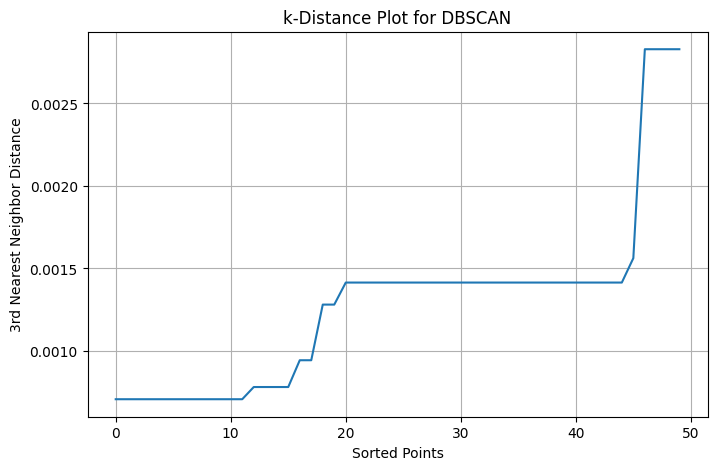

In [20]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X = df[['Latitude', 'Longitude']]

neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, 2])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel('Sorted Points')
plt.ylabel('3rd Nearest Neighbor Distance')
plt.title('k-Distance Plot for DBSCAN')
plt.grid(True)
plt.show()

In [22]:
from sklearn.cluster import DBSCAN

X = df[['Latitude','Longitude']]

dbscan = DBSCAN(
    eps=0.003,
    min_samples=5
)

df['Cluster'] = dbscan.fit_predict(X)

print(df.head())

  Ward  Latitude  Longitude  SWSI  Cluster
0   W1   18.6200    73.8000  89.0        0
1   W2   18.6205    73.8008  85.0        0
2   W3   18.6210    73.8012  87.0        0
3   W4   18.6215    73.8018  82.0        0
4   W5   18.6220    73.8020  90.0        0


In [23]:
hotspots = (
    df[df['Cluster'] != -1]
    .groupby('Cluster')
    .agg({
        'SWSI':'mean',
        'Latitude':'mean',
        'Longitude':'mean'
    })
    .reset_index()
)

hotspots['Priority'] = (
    hotspots['SWSI']
    .rank(ascending=False)
)

print(hotspots)

   Cluster       SWSI   Latitude  Longitude  Priority
0        0  79.111111  18.628556  73.808615       1.0
1        1  45.307692  18.643538  73.823538       2.0
2        2  20.700000  18.654500  73.834500       3.0


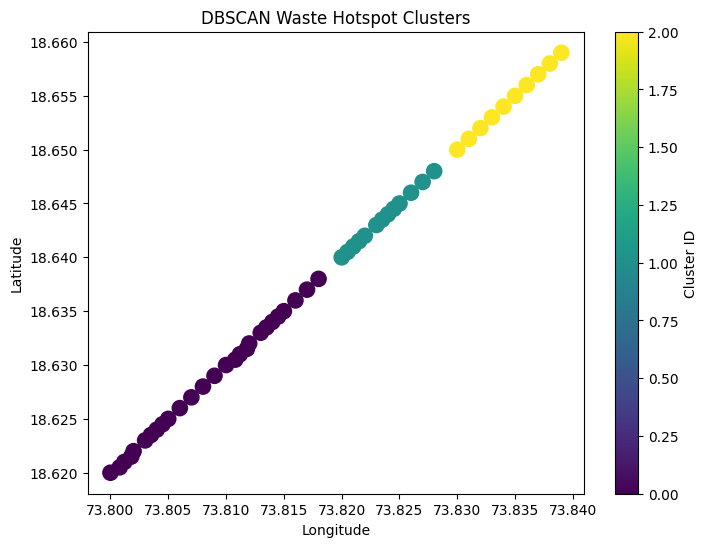

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Cluster'],
    cmap='viridis',
    s=120
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Waste Hotspot Clusters")

plt.colorbar(label="Cluster ID")

plt.show()

In [25]:
from sklearn.cluster import DBSCAN

X = df[['Latitude','Longitude']]

dbscan = DBSCAN(
    eps=0.001,
    min_samples=5
)

labels = dbscan.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

print("Clusters:", clusters)
print("Noise Points:", noise)

Clusters: 0
Noise Points: 50


In [26]:
dbscan = DBSCAN(
    eps=0.003,
    min_samples=5
)

labels = dbscan.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

print("Clusters:", clusters)
print("Noise Points:", noise)

Clusters: 3
Noise Points: 0


In [27]:
dbscan = DBSCAN(
    eps=0.005,
    min_samples=5
)

labels = dbscan.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

print("Clusters:", clusters)
print("Noise Points:", noise)

Clusters: 1
Noise Points: 0
